<a href="https://colab.research.google.com/github/nancysaini00028-droid/Students-marks-predection/blob/main/SEMPP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the dependicies

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor
from sklearn import metrics
import matplotlib.pyplot as plt


Data collection


In [ ]:
#loading the dataset to pandas dataframe
df = pd.read_csv('/content/Exam_Score_Prediction.csv')

Data PreProcessing

In [ ]:
#printing first five rows of the dataset
df.head()


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [ ]:
#number of rows and columns in dataset
df.shape

(20000, 13)

In [ ]:
#getting some information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [ ]:
df['gender'].value_counts()


,count
gender,
other,6726
male,6695
female,6579


In [ ]:
df['course'].value_counts()

,count
course,
bca,2902
ba,2896
b.sc,2878
b.com,2864
bba,2836
diploma,2826
b.tech,2798


In [ ]:
df['internet_access'].value_counts()

,count
internet_access,
yes,16988
no,3012


In [ ]:
df['study_method'].value_counts()

,count
study_method,
self-study,4079
online videos,4069
coaching,4036
group study,3922
mixed,3894


In [ ]:
df['sleep_quality'].value_counts()

,count
sleep_quality,
average,6694
poor,6687
good,6619


In [ ]:
df['facility_rating'].value_counts()

,count
facility_rating,
medium,6760
low,6638
high,6602


In [ ]:
df['exam_difficulty'].value_counts()

,count
exam_difficulty,
moderate,9878
easy,6141
hard,3981


In [ ]:
#statistical measures of the data
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [ ]:
# check for missing values
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


Label Encoding

In [ ]:
encoder = LabelEncoder()

In [ ]:
df['gender'] = encoder.fit_transform(df['gender'])
# 1-male
# 2-female
# 0-Other

In [ ]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,1,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,2,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,1,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,2,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,0,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [ ]:
df['course'] = encoder.fit_transform(df['course'])
df['internet_access'] = encoder.fit_transform(df['internet_access'])
df['study_method'] = encoder.fit_transform(df['study_method'])
df['sleep_quality'] = encoder.fit_transform(df['sleep_quality'])
df['facility_rating'] = encoder.fit_transform(df['facility_rating'])
df['exam_difficulty'] = encoder.fit_transform(df['exam_difficulty'])


In [ ]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,2,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,3,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,4,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,5,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


Splitting the data and Target

In [ ]:
X = df.drop(['exam_score'], axis=1)
Y = df['exam_score']

In [ ]:
print(X)
print(Y)

       student_id  age  gender  course  study_hours  class_attendance  \
0               1   17       1       6         2.78              92.9   
1               2   23       2       5         3.37              64.8   
2               3   22       1       1         7.88              76.8   
3               4   20       2       6         0.67              48.4   
4               5   20       0       6         0.89              71.6   
...           ...  ...     ...     ...          ...               ...   
19995       19997   18       2       4         6.50              71.3   
19996       19998   18       1       0         3.71              41.6   
19997       19999   19       2       6         7.88              68.2   
19998       20000   19       1       4         4.60              76.3   
19999       20001   20       1       1         7.50              47.9   

       internet_access  sleep_hours  sleep_quality  study_method  \
0                    1          7.4              2     

Splitting the data into Training data and Test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)
print(X.shape, X_train.shape, X_test.shape)

(20000, 12) (16000, 12) (4000, 12)


XGBoost Regressor

In [ ]:
# loading the model
model = XGBRegressor()
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Model Evaluation

In [ ]:
# accuracy for prediction on training data
training_data_prediction = model.predict(X_train)


In [ ]:
print(training_data_prediction)

[79.23877  45.095478 70.82267  ... 56.063152 88.114265 76.505684]


In [ ]:
# R squared error
score_1 = metrics.r2_score(Y_train, training_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.8637095826952189
Mean Absolute Error :  5.463619965270997


Visualizing the actual Marks and predicted Marks

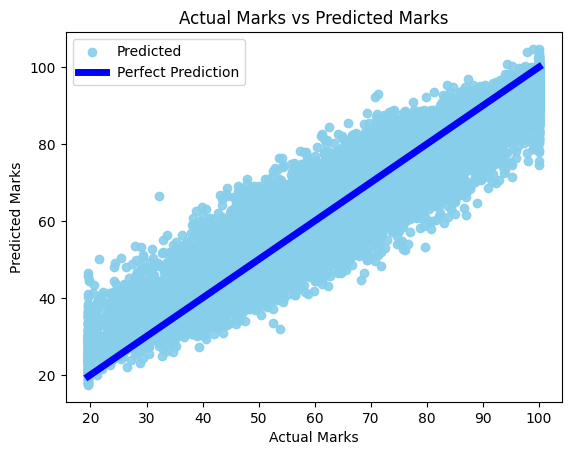

In [ ]:
plt.scatter(Y_train, training_data_prediction,
            color='skyblue', alpha=0.9, label='Predicted')

# Perfect prediction line
plt.plot([min(Y_train), max(Y_train)],
         [min(Y_train), max(Y_train)],
         color='blue', linewidth=5, label='Perfect Prediction')

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Marks vs Predicted Marks")
plt.legend()
plt.show()

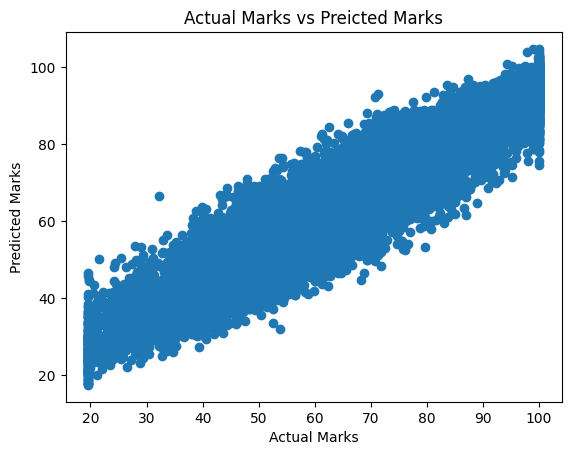

In [ ]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Marks vs Preicted Marks")
plt.show()


Making a predictive system

In [ ]:
input_data = (1,17,1,6,2.78,92.9,1,7.4,2,0,1,1)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped )
print(prediction)


[58.737827]
